In [15]:
# Imports and RFSoC connection
from qick import *
from qick.asm_v2 import AveragerProgramV2
from qick import QickConfig
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import inspect

USE_REMOTE = True

if USE_REMOTE:
    import Pyro4
    Pyro4.config.SERIALIZER = "pickle"
    Pyro4.config.PICKLE_PROTOCOL_VERSION = 4

    ns_host = "10.1.9.48"
    ns_port = 8888
    proxy_name = "myqick"

    ns = Pyro4.locateNS(host=ns_host, port=ns_port)
    soc = Pyro4.Proxy(ns.lookup(proxy_name))
    soccfg = QickConfig(soc.get_cfg())
else:
    soc = QickSoc()
    soccfg = soc

print(soccfg)

QICK running on RFSoC4x2, software version 0.2.414

Firmware configuration (built Fri Jul  3 12:34:42 2026):

	Global clocks (MHz): tProc dispatcher timing 491.520, RF reference 491.520
	Groups of related clocks: [tProc core clock, tProc timing clock, DAC tile 0, DAC tile 2], [ADC tile 0, ADC tile 2]

	2 signal generator channels:
	0:	axis_signal_gen_v6 - fs=7864.320 Msps, fabric=491.520 MHz
		envelope memory: 65536 complex samples (8.333 us)
		32-bit DDS, range=7864.320 MHz
		DAC tile 0, blk 0 is DAC_B
	1:	axis_signal_gen_v6 - fs=7864.320 Msps, fabric=491.520 MHz
		envelope memory: 65536 complex samples (8.333 us)
		32-bit DDS, range=7864.320 MHz
		DAC tile 2, blk 0 is DAC_A

	3 readout channels:
	0:	axis_dyn_readout_v1 - configured by tProc output 2
		fs=4423.680 Msps, decimated=552.960 MHz, 32-bit DDS, range=4423.680 MHz
		axis_avg_buffer v1.2 (has edge counter, no weights)
		memory 16384 accumulated, 16384 decimated (29.630 us)
		triggered by tport 0, pin 0, feedback to tProc input

In [16]:
gen_ch = 0
ro_ch = 0

In [17]:
base = Path('.')
real_data = np.load(base /'adc_recovered_50k.npy')
shot_idx = 0
dac_waveform = real_data[shot_idx]

In [18]:
def calculate_waveform_vals(shot):
    waveform = np.asarray(shot, dtype=float).reshape(-1)

    if waveform.size == 0:
        return {
            "waveform": waveform,
            "gain": 0.0,
            "freq": 0.0,
            "phase": 0.0,
            "length": 0,
        }

    gain = float(np.max(np.abs(waveform)))
    length = 2.78501157#11.14#int(waveform.size)

    if waveform.size > 1:
        spectrum = np.fft.rfft(waveform)
        freqs = np.fft.rfftfreq(waveform.size, d=1.0)

        if spectrum.size > 1:
            dominant_idx = np.argmax(np.abs(spectrum[1:])) + 1
        else:
            dominant_idx = 0

        freq = float(freqs[dominant_idx]) if freqs.size else 0.0
        phase = float(np.angle(spectrum[dominant_idx]))
    else:
        freq = 0.0
        phase = 0.0

    return {
        "waveform": waveform,
        "gain": gain,
        "freq": freq,
        "phase": phase,
        "length": length,
    }


In [19]:
base_config = {
    "gen_ch": gen_ch,
    "ro_ch": ro_ch,
    "nqz": 1,

    "reps": 1,
    "soft_avgs": 1,
    "final_delay": 100,

    "readout_length": 2.3,#2.78501157,#11.14,
    "adc_trig_offset": 100,

    # "gain": 1.0,
    # "freq": 0,
    # "phase": 0,

    "mode": "oneshot",
    "stdysel": "zero",
    "outsel": "input",
}

(6160,)
-1370.865703143668
347.5342104871613


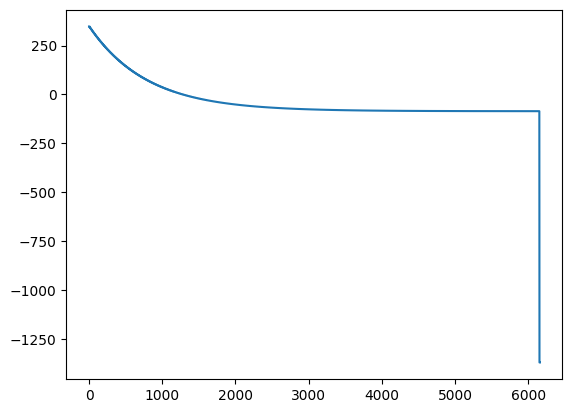

In [20]:
print(dac_waveform.shape)
print(dac_waveform.min())
print(dac_waveform.max())

plt.plot(dac_waveform)

In [21]:
shot_info = calculate_waveform_vals(dac_waveform)

def update_config(base_config, shot_info):
    config = base_config.copy()
    config.update(shot_info)
    return config

In [22]:
config = base_config.copy()
config.update(shot_info)

In [23]:
class LoopbackProgram(AveragerProgramV2):

    def __init__(self, soccfg, cfg):
        super().__init__(
            soccfg,
            reps=cfg["reps"],
            final_delay=cfg["final_delay"],
            cfg=cfg,
        )

    def _initialize(self, cfg):
        self.declare_gen(
            ch=cfg["gen_ch"],
            nqz=cfg["nqz"]
        )

        self.declare_readout(
            ch=cfg["ro_ch"],
            length=cfg["readout_length"]
        )

        # load arbitrary waveform into memory
        self.add_envelope(
            ch=cfg["gen_ch"],
            name="readout_env",
            idata=cfg["waveform"],
            qdata=np.zeros_like(cfg["waveform"])
        )

        # create pulse using envelope
        self.add_pulse(
            ch=cfg["gen_ch"],
            name="readout_pulse",
            style="arb",
            envelope="readout_env",
            gain=cfg["gain"],
            freq=cfg["freq"],
            phase=cfg["phase"],
            outsel=cfg["outsel"],
            mode=cfg["mode"],
            stdysel=cfg["stdysel"],
            ro_ch=cfg["ro_ch"]
        )

        # configure the readout block used by the acquisition loop
        self.add_readoutconfig(
            ch=cfg["ro_ch"],
            name="ro_cfg",
            freq=cfg["freq"],
            gen_ch=cfg["gen_ch"]
        )

    def _body(self, cfg):
        self.pulse(
            ch=cfg["gen_ch"],
            name="readout_pulse"
        )

        self.send_readoutconfig(
            ch=cfg["ro_ch"],
            name="ro_cfg",
            t=0
        )

        self.trigger(
            ros=[cfg["ro_ch"]],
            pins=[0],
            t=cfg["adc_trig_offset"],
            width=10
        )

In [24]:
base = Path('.')
real_data = np.load(base /'dac_waveform_shot0.npy')
dac_waveform = real_data#[0]

In [25]:
# config = {
#     # -----------------------
#     # Hardware
#     # -----------------------
#     "gen_ch": gen_ch,
#     "ro_ch": ro_ch,
#     "nqz": 1,

#     # -----------------------
#     # Experiment
#     # -----------------------
#     "reps": 1,
#     "soft_avgs": 1,
#     "final_delay": 100,

#     # -----------------------
#     # Readout
#     # -----------------------
#     "readout_length": 100,
#     "adc_trig_offset": 100,

#     # -----------------------
#     # Pulse
#     # -----------------------
#     "waveform": dac_waveform,
#     "gain": 1.0,
#     "freq": 0,
#     "phase": 0,

#     "mode": "oneshot",
#     "stdysel": "zero",
#     "outsel": "input",
# }

In [26]:
import gc

# Load the waveform dataset and make sure each row is a 1D waveform.
#dataset_path = base / 'adc_recovered_50k.npy'
dataset_path = base / 'adc_recovered_1k_truncated.npy'
if dataset_path.exists():
    dataset = np.load(dataset_path)
else:
    dataset = np.load(base / 'dac_waveform_shot0.npy')

if dataset.ndim == 1:
    dataset = dataset[np.newaxis, :]


def prepare_waveform(waveform):
    arr = np.asarray(waveform, dtype=float).reshape(-1)
    if arr.size == 0:
        return np.zeros(16, dtype=float)

    # QICK requires the envelope length to be an integer multiple of 16.
    if arr.size % 16 != 0:
        target_len = int(np.ceil(arr.size / 16) * 16)
        if arr.size < target_len:
            arr = np.pad(arr, (0, target_len - arr.size), mode='constant')
        else:
            arr = arr[:target_len]

    return arr

max_rows = dataset.shape[0]
acquired_rows = []

for idx in range(max_rows):
    waveform = prepare_waveform(dataset[idx])

    shot_info = calculate_waveform_vals(waveform)
    config = base_config.copy()
    config.update(shot_info)
    config['waveform'] = waveform
    config['shot_idx'] = idx

    prog = LoopbackProgram(soccfg, config)
    iq = prog.acquire_decimated(soc)

    if isinstance(iq, list):
        record = np.concatenate([np.asarray(arr).reshape(-1) for arr in iq])
    else:
        record = np.asarray(iq).reshape(-1)

    acquired_rows.append(record)

    if idx % 1000 == 0 or idx == max_rows - 1:
        print(f'processed {idx + 1}/{max_rows} shots')

    del prog, iq, config, shot_info, waveform, record
    gc.collect()

acquired_data = np.vstack(acquired_rows)
output_path = base / 'acquired_dataset.npy'
np.save(output_path, acquired_data)
print(f'saved {acquired_data.shape[0]} acquired rows to {output_path}')

  0%|          | 0/1 [00:00<?, ?it/s]

processed 1/1000 shots


  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

...

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

processed 1000/1000 shots
saved 1000 acquired rows to acquired_dataset.npy


In [27]:
print(type(iq))
print(iq)

NameError: name 'iq' is not defined

In [ ]:
#iq = prog.acquire(soc)

print("type(iq):", type(iq))
if isinstance(iq, list):
    print("iq is a list of arrays, one per readout channel")
    for i, arr in enumerate(iq):
        print(f"channel {i}: shape={getattr(arr, 'shape', None)}")
else:
    print("iq shape:", iq.shape)


type(iq): <class 'list'>
iq is a list of arrays, one per readout channel
channel 0: shape=(6160, 2)


In [ ]:
print(type(iq))

for ch, arr in enumerate(iq):
    arr = np.asarray(arr)

    print(f"Channel {ch}")
    print(" shape:", arr.shape)
    print(arr)

<class 'list'>
Channel 0
 shape: (6160, 2)
[[ 2. -6.]
 [ 1. -4.]
 [ 0.  1.]
 ...
 [ 0. -1.]
 [ 1. -4.]
 [ 2. -5.]]


channel array shape: (6160, 2)


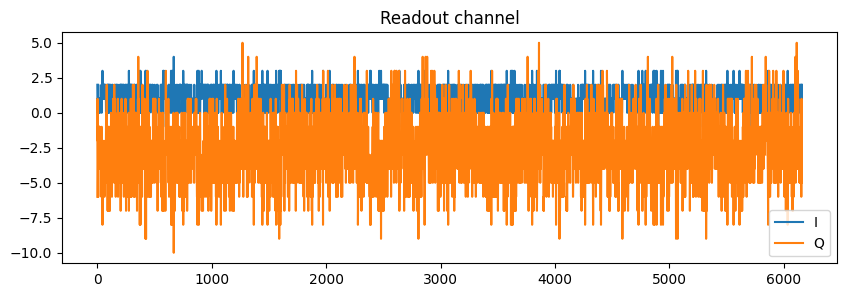

In [ ]:
# plot iq
if isinstance(iq, list):
    fig, axes = plt.subplots(len(iq), 1, figsize=(10, 3*len(iq)))
    if len(iq) == 1:
        axes = [axes]
    for ax, arr in zip(axes, iq):
        arr = np.asarray(arr)
        print("channel array shape:", arr.shape)
        if arr.ndim == 1:
            if arr.size >= 2:
                ax.plot([0, 1], arr[:2], marker='o')
                ax.set_xticks([0, 1])
                ax.set_xticklabels(['I', 'Q'])
            else:
                ax.plot(arr, marker='o')
        elif arr.ndim >= 2 and arr.shape[-1] == 2:
            ax.plot(arr[:, 0], label='I')
            ax.plot(arr[:, 1], label='Q')
        else:
            ax.plot(arr.reshape(-1), label='data')
        ax.set_title('Readout channel')
        ax.legend()
else:
    plt.figure(figsize=(10, 6))
    plt.plot(iq)